In [101]:
import numpy as np
import matplotlib.pyplot as plt


def initialize_lattice(N, mode="random"):
    """
    Initialize a 2D square lattice of size N x N.

    Parameters
    ----------
    N : int
        Lattice size.
    mode : str
        "random", "up", or "down".

    Returns
    -------
    lattice : numpy array
        N x N array with spins +1 or -1.
    """

    if mode == "random":
        return np.random.choice([-1, 1], size=(N, N))

    elif mode == "up":
        return np.ones((N, N), dtype=int)

    elif mode == "down":
        return -np.ones((N, N), dtype=int)

    else:
        raise ValueError("Mode must be 'random', 'up', or 'down'.")


def calculate_energy(lattice, J=1.0, h=0.0):
    """
    Calculate the total energy of the 2D Ising lattice.

    Uses periodic boundary conditions.

    Parameters
    ----------
    lattice : numpy array
        Spin lattice.
    J : float
        Interaction strength.
    h : float
        External magnetic field.

    Returns
    -------
    energy : float
        Total energy of the system.
    """

    N = lattice.shape[0]
    energy = 0.0

    for i in range(N):
        for j in range(N):
            spin = lattice[i, j]

            # Count only right and down neighbors to avoid double counting
            right_neighbor = lattice[i, (j + 1) % N]
            down_neighbor = lattice[(i + 1) % N, j]

            energy += -J * spin * (right_neighbor + down_neighbor)

            # External field contribution
            energy += -h * spin

    return energy


def calculate_magnetization(lattice):
    """
    Calculate the total magnetization.

    Parameters
    ----------
    lattice : numpy array
        Spin lattice.

    Returns
    -------
    magnetization : int
        Sum of all spins.
    """

    return np.sum(lattice)


def monte_carlo_sweep(lattice, T, J=1.0, h=0.0):
    """
    Perform one Monte Carlo sweep using the Metropolis algorithm.

    One sweep means attempting N x N spin flips.

    Parameters
    ----------
    lattice : numpy array
        Spin lattice.
    T : float
        Temperature.
    J : float
        Interaction strength.
    h : float
        External magnetic field.

    Returns
    -------
    lattice : numpy array
        Updated spin lattice.
    """

    N = lattice.shape[0]

    for _ in range(N * N):

        # Choose a random spin
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)

        spin = lattice[i, j]

        # Periodic boundary conditions
        up = lattice[(i - 1) % N, j]
        down = lattice[(i + 1) % N, j]
        left = lattice[i, (j - 1) % N]
        right = lattice[i, (j + 1) % N]

        neighbor_sum = up + down + left + right

        # Energy change if this spin is flipped
        delta_E = 2 * spin * (J * neighbor_sum + h)

        # Metropolis acceptance rule
        if delta_E < 0:
            lattice[i, j] *= -1
        else:
            probability = np.exp(-delta_E / T)
            if np.random.rand() < probability:
                lattice[i, j] *= -1

    return lattice


def run_simulation(
    N,
    T,
    J=1.0,
    h=0.0,
    thermalization_sweeps=1000,
    measurement_sweeps=1000,
    initialization="random"
):
    """
    Run the full Ising model simulation.

    Parameters
    ----------
    N : int
        Lattice size.
    T : float
        Temperature.
    J : float
        Interaction strength.
    h : float
        External magnetic field.
    thermalization_sweeps : int
        Number of sweeps before measurements.
    measurement_sweeps : int
        Number of sweeps used for measurements.
    initialization : str
        Initial lattice mode: "random", "up", or "down".

    Returns
    -------
    avg_energy_per_spin : float
        Average energy per spin.
    avg_magnetization_per_spin : float
        Average magnetization per spin.
    """

    lattice = initialize_lattice(N, mode=initialization)

    # Thermalization stage
    for _ in range(thermalization_sweeps):
        monte_carlo_sweep(lattice, T, J, h)

    energies = []
    magnetizations = []

    # Measurement stage
    for _ in range(measurement_sweeps):
        monte_carlo_sweep(lattice, T, J, h)

        E = calculate_energy(lattice, J, h)
        M = calculate_magnetization(lattice)

        energies.append(E)
        magnetizations.append(M)

    total_spins = N * N

    avg_energy_per_spin = np.mean(energies) / total_spins
    avg_magnetization_per_spin = np.mean(magnetizations) / total_spins

    return avg_energy_per_spin, avg_magnetization_per_spin, energies, magnetizations

In [ ]:
# Parameters
N = 40
J = 1.0

# temperatures = [1.5, 2.3, 4.0]
# fields = [0.0, 0.5, 2.0]

temperatures = [0.5, 2.5, 4.0 ]
fields = [0, 0.5, 2.0]
thermalization_sweeps = 100
measurement_sweeps = 10000

results = {}

for h in fields:
    avg_energies = []
    avg_magnetizations = []
    energies = []
    magnetizations = []
    print(f"\nRunning simulations for h = {h}")

    for T in temperatures:
        avg_E, avg_M, all_energies, all_magnetizations = run_simulation(
            N=N,
            T=T,
            J=J,
            h=h,
            thermalization_sweeps=thermalization_sweeps,
            measurement_sweeps=measurement_sweeps,
            initialization="random"
        )

        avg_energies.append(avg_E)
        avg_magnetizations.append(avg_M)
        energies.append(all_energies)
        magnetizations.append(all_magnetizations)
        print(f"T = {T:.2f}, <E>/spin = {avg_E:.4f}, <M>/spin = {avg_M:.4f}")

    results[h] = {
        "temperatures": temperatures,
        "energies_avg": avg_energies,
        "magnetizations_avg": avg_magnetizations,
        "energies": energies,
        "magnetizations": magnetizations
    }


Running simulations for h = 0
T = 0.50, <E>/spin = -1.9852, <M>/spin = -0.9303
T = 2.50, <E>/spin = -1.1030, <M>/spin = -0.0234
T = 4.00, <E>/spin = -0.5564, <M>/spin = -0.0016

Running simulations for h = 0.5
T = 0.50, <E>/spin = -2.5000, <M>/spin = 1.0000
T = 2.50, <E>/spin = -2.1306, <M>/spin = 0.9002
T = 4.00, <E>/spin = -1.0121, <M>/spin = 0.4521

Running simulations for h = 2.0
T = 0.50, <E>/spin = -4.0000, <M>/spin = 1.0000
T = 2.50, <E>/spin = -3.8909, <M>/spin = 0.9813
T = 4.00, <E>/spin = -3.2463, <M>/spin = 0.8594


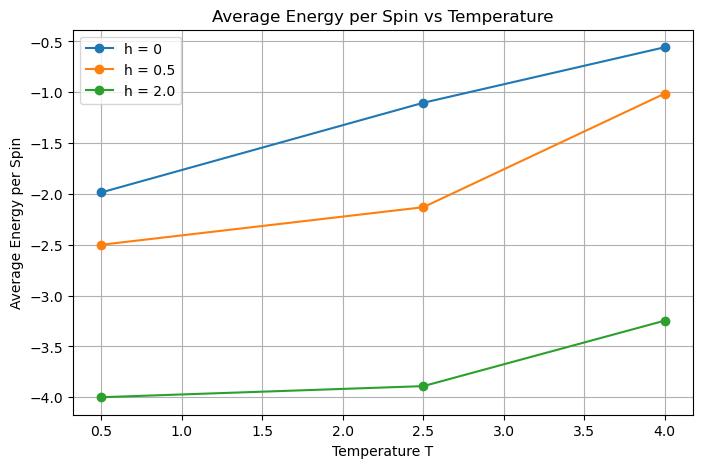

In [107]:
plt.figure(figsize=(8, 5))

for h in fields:
    plt.plot(
        results[h]["temperatures"],
        results[h]["energies_avg"],
        marker="o",
        label=f"h = {h}"
    )

plt.xlabel("Temperature T")
plt.ylabel("Average Energy per Spin")
plt.title("Average Energy per Spin vs Temperature")
plt.legend()
plt.grid(True)
plt.show()




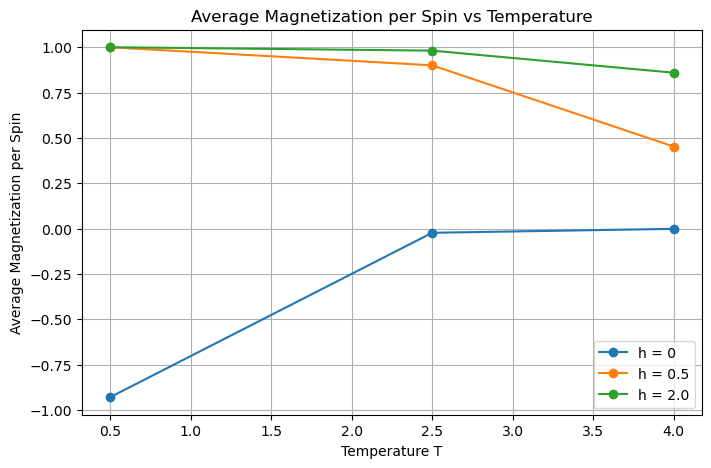

In [108]:
plt.figure(figsize=(8, 5))

for h in fields:
    plt.plot(
        results[h]["temperatures"],
        results[h]["magnetizations_avg"],
        marker="o",
        label=f"h = {h}"
    )

plt.xlabel("Temperature T")
plt.ylabel("Average Magnetization per Spin")
plt.title("Average Magnetization per Spin vs Temperature")
plt.legend()
plt.grid(True)
plt.show()